# Study · The monitoring system of the Mura Urbiche di Gubbio, and its record

This study documents the static structural health monitoring installation on the
medieval urban walls of Gubbio and the record it has produced since July 2018. It is
the first document to read in this project: every other study assumes the
instrumentation, the file format, the thermal compensation and the shape of the
archive, and this one states them.

**It reads the raw archive itself**, on the native 20-minute grid, and it is the study
that decides what in that archive is a measurement and what is not. A document whose
subject is the record cannot be handed that record already cleaned: the wall-temperature
probe spent eight months reporting a failure sentinel, and an ingest that turned those
readings into gaps before this study opened them would have hidden exactly what this
study exists to report.

Nothing here aggregates. The hourly grid the rest of the pipeline works on exists so
that the sensor record can be aligned against hourly external proxies, which is a
property of those proxies rather than of this archive; building it belongs to the study
that prepares that comparison.

1. **Read the raw archive** — every `.adc` file, both column layouts, no cleaning.
2. **What the raw record contains** — every documented defect, counted and dated.
3. **Flag, correct, compensate** — the verdicts applied, and the inclination carried
   through its correction chain.
4. **Coverage of the inclination record** — how much each station contributes, and
   when the network narrowed from three instrumented locations to one.
5. **The instrument changeover** — the level step at the February 2025 replacement,
   the seasonal part of it, and the gain diagnostic that qualifies the estimate.
6. **Station 02, variable by variable** — the compensated inclination first, then the
   summer 2026 anomaly and the filtering that removes its impulsive noise, the diurnal
   cycle by era and season, then the air temperature and the relative humidity, each
   with its own record and its own diurnal cycle, and finally the supply voltage.
7. **The current era** — the wall temperature and the solar radiation, which exist
   nowhere in the legacy record.
8. **The exported archive** — one table, every value as recorded, why it was rejected,
   and what it was corrected to.

Step 6 follows the order of section *Station 02, variable by variable* in the report,
so the figures are produced in the order the report reads them.

The narrative, the instrumentation description and the file-format specification are
in `report/data_exploration_report.pdf`. This notebook produces the numbers and the
figures that report reads.

## Imports and configuration

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

sys.path.insert(0, os.path.abspath('.'))       # de_lib, local to this study
sys.path.insert(0, os.path.abspath('..'))      # studies/, for shmlib
sys.path.insert(0, os.path.abspath('../..'))   # heritageshm, at the repo root

import de_lib as de
from shmlib import tables, viz

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 80)

### Parameters

| Parameter | Purpose |
|---|---|
| `RAW_ARCHIVE_DIR` | **The one data path.** The read-only `.adc` archive, outside this repository. It is never written to, moved, or copied into the project except into the local cache below. |
| `CACHE_DIR` | Local working copy of the archive. Google Drive serves the archive at roughly ten files per minute, so the first run is slow and every later one reuses this. |
| `ARCHIVE_START`, `ARCHIVE_END` | Day bounds to read. `ARCHIVE_END = None` discovers the newest file present, so the run adapts as the archive grows. |
| `ANALYSIS_FREQ` | The grid this study works on: 20 minutes, the rate the acquisition system actually records at. Nothing here aggregates. |
| `OUTPUT_DIR` | Where this study's tables, table bodies and figures are written. |
| `EXPORT_DIR`, `COMPRESS` | Where the archive table is written, and whether to gzip it. |
| `STATION` | The station carried through steps 3 and 4. Station 02, at the Porta di Sant'Ubaldo, is the best covered and the only one spanning both instrument eras. |
| `STATIONS` | Every station in the archive, for the coverage comparison of step 2. |
| `CHANGEOVER` | The date the expanded instrument package replaced the legacy network. Marked on the inclination and single-channel figures; the anomaly and diurnal figures do not span it. |
| `CHANNELS` | The four channels plotted one by one in step 4. |
| `ANOMALY_START` | First day of the summer 2026 excursion. Shaded on the inclination figures and used as the left edge of the anomaly comparison; the right edge is always the end of the archive. |
| `HISTORICAL_END` | Last day counted as history when the anomaly is compared with earlier years. Everything after it is the anomaly year itself and must be excluded from its own reference. |
| `HAMPEL_WINDOW`, `HAMPEL_SIGMAS`, `HAMPEL_FLOOR` | Rolling-window length in samples, the outlier threshold in robust standard deviations, and a floor on that threshold in mdeg. The window is 72 samples, which is 24 hours on the native grid. The floor stops the filter from cutting into quiet stretches, where the rolling deviation is so small that ordinary measurement noise would exceed the threshold. |
| `TWALL_FILTER_START` | First timestamp of the final wall-temperature recording segment. Only this segment is tested for impulsive anomalies. |
| `TWALL_HAMPEL_WINDOW`, `TWALL_HAMPEL_SIGMAS`, `TWALL_HAMPEL_FLOOR` | Wall-temperature impulse test: a centred three-sample window, three robust standard deviations, and a 10 °C minimum threshold. The short window detects samples that leave and rejoin a smooth thermal trajectory within forty minutes. |
| `SLOTS_PER_DAY`, `COMPLETE_DAY` | Slots of the analysis grid in one day, and how many of them a day must carry to enter a diurnal average. They are equal: a day missing any slot is excluded rather than interpolated, so that a partly observed day cannot bias a mean towards the part of the day it happens to cover. |
| `ERAS`, `DIURNAL_SEASONS`, `SEASON_MONTHS` | The two instrument eras, the season pair every diurnal comparison is drawn on, and the months belonging to each of the four seasons. Summer and winter are the extremes of the Central Italian year; holding the pair fixed is what makes the current-era channels readable against everything before them. Substituting a fuller season would hide the cost of the channels that cannot support a winter. |
| `COVERAGE_COL`, `RECORDED_COL` | Which channel's presence counts as an observation. Coverage of the *record* is asked of the compensated series, because that is what a later study receives; coverage of the *instrument* is asked of the recorded channel, which exists wherever the unit wrote anything at all. |
| `RESPONSE_COL`, `DRIVER_COL` | The structural response, and the forcing its amplitude is divided by to give a sensitivity in mdeg per °C. Changing the driver changes what "normalised" means and therefore what the changeover comparison is testing. |
| `AVAILABILITY_CHANNELS`, `ERA_CHANNELS`, `PHASE_CHANNELS`, `PHASE_SEASON` | Channels reported in the current-era availability table, drawn in its coverage strip, and carried through the thermal chain, plus the season that chain is averaged over. The chain is ordered sun, air, masonry, deformation, which is the order the figure is read in. |
| `ANOMALY_COL`, `ANOMALY_CHANNELS` | The channel the summer 2026 excursion is measured on, and the channels asked whether they carry it. A real thermal or hygric event must appear in the environmental channels; a fault in the acquisition chain need not. |
| `EXCURSION_LIMIT` | Millidegrees below which a current-era sample counts as an extreme excursion. Not a filter — nothing is removed by it — only a line drawn an order of magnitude beyond the ordinary spread, so the extreme population can be counted and dated separately. |
| `OUTLIER_SIGMAS`, `RESIDUAL_WINDOW`, `DAYLIGHT_HOURS` | The anomaly test: departures beyond this many robust standard deviations of a channel's own quiet-period noise are counted, measured against a centred rolling median of this length, with excursions between these hours counted as falling in daylight. Raising the sigma count makes every channel look quieter without changing which of them carries the event. |
| `ROBUST_QUANTILES`, `ROBUST_PAD` | The inner quantile range the two long inclination figures are drawn on, and the padding outside it. A display choice only: no data and no statistic is affected, and each clipped panel says how many samples it is not showing. |
| `CLOCK_SMOOTH_DAYS` | Length of the centred rolling median used to locate the daylight-saving step in the measured clock offset. A single day's estimate scatters by half an hour, so the step is sought in the smoothed series where ordinary scatter cannot out-rank it. |
| `SR_DEAD_THRESHOLD` | High-sun median in W/m² below which a condemned radiation day counts as dead rather than stuck. It partitions the condemned days, so the two modes and the accounting of the whole failure window cannot disagree. |
| `SR_AXIS_STEP`, `SR_FAILURE_MARGIN_DAYS`, `SR_STATE_LABEL` | The radiation figures: the vertical axis is rounded up to a multiple of the step so the wrap-around is shown at the magnitude it claims; the failure figure draws this many days of context either side; and each failure state carries a short label, keyed on the taxonomy in `de.SR_STATES` so the two cannot drift apart. |
| `HISTORICAL_LABEL`, `ANOMALY_TICK_DAYS`, `ANOMALY_PANEL_TICK_DAYS`, `SEGMENT_TICK_DAYS` | Legend text of the historical reference, and the date-tick spacing of the anomaly figures, the anomaly panel and the wall-temperature segment figures. |
| `CHANNELS`, `CHANNEL_LABEL`, `CHANNEL_COLOUR`, `INC_COLOUR`, `MARK_COLOUR`, `SPAN_STYLE`, `LEGACY_STYLE`, `CURRENT_STYLE` | The project's colour and label scheme, bound from `shmlib.viz`, where a channel's identity is fixed for every figure of every study. Colour carries variable identity and nothing else; where two eras must be told apart inside one axes the distinction is line style. |
| `CHANNEL_UNIT_TEX`, `DIURNAL_NAME`, `ANOMALY_LABEL` | How the report's tables and the anomaly panel name and unit each channel. LaTeX markup rather than data, so it reaches the table bodies unescaped. Two tables name their channels more briefly than the shared labels do, because their rows are already qualified by the table's caption. |

In [2]:
RAW_ARCHIVE_DIR = os.path.expanduser(
    '~/Library/CloudStorage/GoogleDrive-eugeniomoreira@iaud.ufc.br/'
    'My Drive/_UNIPG/__Mura-realtime'
)
CACHE_DIR = '.cache'
OUTPUT_DIR = 'outputs'
EXPORT_DIR = '../../data/interim/archive'
COMPRESS = False

ARCHIVE_START = de.ARCHIVE_START
ARCHIVE_END = None             # None: discover the newest file in the archive
ANALYSIS_FREQ = de.SAMPLING    # 20 minutes, the native rate
SLOTS_PER_DAY = int(pd.Timedelta('1D') / pd.Timedelta(ANALYSIS_FREQ))   # 72

STATION = de.TARGET_STATION
STATIONS = de.LEGACY_BLOCKS
CHANGEOVER = pd.Timestamp(de.CURRENT_START)

CHANNELS = ['inc_comp', 'tair', 'rh', 'batt']
CHANNEL_LABEL = viz.CHANNEL_LABEL

# Which channel's presence counts as an observation. Coverage of the *record* is asked
# of the compensated series, because that is what a later study receives; coverage of
# the *instrument* is asked of the recorded channel, which exists wherever the unit
# wrote anything at all.
COVERAGE_COL = 'inc_comp'
RECORDED_COL = 'inc'

# The clipped display range of the two long inclination figures: the inner quantile
# range retained, and the padding added outside it.
ROBUST_QUANTILES = (0.005, 0.995)
ROBUST_PAD = 0.05

# Units as the report typesets them. LaTeX, not text: these strings reach the table
# bodies unescaped, because they are markup rather than data.
CHANNEL_UNIT_TEX = {
    'inc_comp': 'mdeg',
    'inc_comp_cleaned': 'mdeg',
    'tair': r'\textdegree C',
    'twall_filtered': r'\textdegree C',
    'rh': r'\%',
    'batt': 'V',
    'sr': 'W/m$^2$',
}

# Two tables name the channels more briefly than the shared labels do, because their
# rows are already qualified by the table's own caption. They are presentation choices
# of those tables and are declared here rather than taken from `viz`.
DIURNAL_NAME = {'inc_comp_cleaned': 'Inclination', 'tair': 'Air temperature',
                'rh': 'Relative humidity'}
ANOMALY_LABEL = {'inc_comp': 'Inclination [mdeg]', 'tair': 'Air temp. [°C]',
                 'rh': 'Relative humidity [%]', 'batt': 'Supply voltage [V]'}

ANOMALY_START = pd.Timestamp('2026-06-18')
HISTORICAL_END = pd.Timestamp('2025-12-31')

# Eras and seasons. Summer and winter are the two extremes of the Central Italian year
# and are the pair every diurnal comparison in this study is made on; holding the pair
# fixed is what makes the current-era channels readable against everything before them.
ERAS = ('legacy', 'current')
DIURNAL_SEASONS = ('summer', 'winter')
SEASON_MONTHS = {'winter': [12, 1, 2], 'spring': [3, 4, 5],
                 'summer': [6, 7, 8], 'autumn': [9, 10, 11]}
COMPLETE_DAY = SLOTS_PER_DAY      # slots a day must carry to enter a diurnal average

# The response and the forcing it is normalised by, and the channels each current-era
# table reports.
RESPONSE_COL = 'inc_comp_cleaned'
DRIVER_COL = 'tair'
AVAILABILITY_CHANNELS = ['inc_comp_cleaned', 'tair', 'rh', 'batt', 'twall', 'sr']
ERA_CHANNELS = ['twall', 'sr']
PHASE_CHANNELS = ['sr', 'tair', 'twall_filtered', 'inc_comp_cleaned']
# Days of the smoothing window used to locate the daylight-saving step, and the high-sun
# median below which a condemned radiation day counts as dead rather than stuck.
CLOCK_SMOOTH_DAYS = 7
SR_DEAD_THRESHOLD = 10.0          # W/m²

# How the anomaly figures label and tick themselves.
HISTORICAL_LABEL = 'Historical average (2018-2025)'
ANOMALY_TICK_DAYS = 5
ANOMALY_PANEL_TICK_DAYS = 7
SEGMENT_TICK_DAYS = 7

# The radiation figures: the vertical axis is rounded up to a multiple of this, so the
# wrap-around is shown at the magnitude it actually claims; the failure figure draws
# this many days of context either side; and each failure state carries a short label,
# keyed on the taxonomy itself so the two cannot drift apart.
SR_AXIS_STEP = 500.0
SR_FAILURE_MARGIN_DAYS = 10
SR_STATE_LABEL = {
    de.SR_STATES[2]: 'dead',
    de.SR_STATES[3]: 'stuck',
    de.SR_STATES[1]: 'pegged',
    de.SR_STATES[0]: 'no record',
}

# The season the thermal chain is drawn on.
PHASE_SEASON = 'summer'

# The summer 2026 excursion, examined channel by channel. The threshold below is not a
# filter: nothing is removed by it, and it exists so that the extreme population can be
# counted and dated separately from the record it is buried in.
ANOMALY_COL = 'inc_comp'
ANOMALY_CHANNELS = ['inc_comp', 'tair', 'rh', 'batt']
EXCURSION_LIMIT = -300.0          # mdeg
OUTLIER_SIGMAS = 5                # departures beyond this many robust deviations count
RESIDUAL_WINDOW = SLOTS_PER_DAY   # 24 hours, the window the Hampel filter also uses
DAYLIGHT_HOURS = (9, 16)          # inclusive hours counted as daylight

HAMPEL_WINDOW = SLOTS_PER_DAY   # 24 hours, in samples of the native grid
HAMPEL_SIGMAS = 3
HAMPEL_FLOOR = 10.0

TWALL_FILTER_START = pd.Timestamp('2026-06-18')
TWALL_HAMPEL_WINDOW = 3
TWALL_HAMPEL_SIGMAS = 3
TWALL_HAMPEL_FLOOR = 10.0

# The project's colour scheme, defined once in `shmlib.viz` and bound to local names here
# so the plotting cells below read as they always have. Okabe-Ito, per the Graphical
# Guidelines in `instructions-pipeline.md`: colour carries variable identity, so every
# figure of a given channel is drawn in that channel's colour and a reader recognises the
# quantity before reading the axis. Where the two instrument eras must be told apart inside
# a single axes, the distinction is line style, not colour — colour is spent on identity
# and cannot also carry the era. The accent marks events and annotations and never encodes
# a data category.
MARK_COLOUR = viz.MARK_COLOUR    # Vermilion — accent: changeover, markers, annotations
SPAN_STYLE = viz.SPAN_STYLE
CHANNEL_COLOUR = viz.CHANNEL_COLOUR
INC_COLOUR = viz.INC_COLOUR
channel_style = viz.channel_style

LEGACY_STYLE = viz.LEGACY_STYLE  # Era is line style, so colour stays free for identity
CURRENT_STYLE = viz.CURRENT_STYLE

apply_report_style = viz.apply_report_style
format_spines = viz.format_spines

os.makedirs(OUTPUT_DIR, exist_ok=True)

## Step 1 · Read the raw archive

The archive is copied to a local cache, then parsed twice: once with the 14-field
legacy parser and once with the 20-field current-era one. Both passes see the whole
file list, because the era of a record is decided by its own field count and never by
the date on the filename it arrived in — seven current-era records are written into
files dated before the changeover, and a loader that branched on the date would lose
them.

The text scan that runs first counts what no parser can pass on. A malformed record has
to be skipped for the file to be read at all, and once skipped it is invisible; this
study reports the archive rather than only the part of it that parses, so those records
are counted before they disappear.

Nothing here cleans anything. Every value below is exactly what the acquisition system
wrote, sentinels included.

In [3]:
if ARCHIVE_END is None:
    ARCHIVE_END = de.last_archive_day(RAW_ARCHIVE_DIR)
print(f'Archive {ARCHIVE_START} to {ARCHIVE_END}')

paths = de.sync_archive(RAW_ARCHIVE_DIR, CACHE_DIR, ARCHIVE_START, ARCHIVE_END)

text_stats = de.scan_raw_text(paths)
print(f'  {text_stats["lines"]} records read: {text_stats["n_legacy"]} legacy, '
      f'{text_stats["n_current"]} current, {text_stats["rejected"]} rejected on '
      f'field count')
print(f'  {text_stats["comma_fields"]} numeric fields use a comma decimal separator, '
      f'in {text_stats["mixed_separator_files"]} files that also use a point')

legacy_raw, legacy_stats = de.parse_era(paths, 'legacy')
current_raw, current_stats = de.parse_era(paths, 'current')
parse_stats = {'legacy': legacy_stats, 'current': current_stats}

grid = de.build_grid(ARCHIVE_START, ARCHIVE_END, freq=ANALYSIS_FREQ)
wide = de.assemble_wide(legacy_raw, current_raw, grid)

print(f'\nGrid: {len(wide)} slots at {ANALYSIS_FREQ}, '
      f'{wide.index.min()} to {wide.index.max()}')
print(f'Recorded: {wide["era"].value_counts().to_dict()}')

# Where the two layouts actually meet, as opposed to where the documented changeover date
# puts them. Branching on the field count is what makes this visible at all.
legacy_last = wide.index[wide['era'] == 'legacy'].max()
current_first = wide.index[wide['era'] == 'current'].min()
print(f'Era boundary observed: last 14-field record {legacy_last}, '
      f'first 20-field record {current_first}')
print(f'  documented changeover date: {CHANGEOVER.date()}')

Archive 2018-07-26 to 2026-08-21
  cache: 2353 files in range, 0 newly copied, 2353 already present


  scanning:   0%|          | 0/2353 [00:00<?, ?file/s]

  177839 records read: 147631 legacy, 30208 current, 0 rejected on field count
  501672 numeric fields use a comma decimal separator, in 68 files that also use a point


  parsing legacy:   0%|          | 0/2353 [00:00<?, ?file/s]

  legacy  : 147631 records from 2353 files, 19216 sharing a timestamp (18473 field conflicts merged), 133687 distinct timestamps


  parsing current:   0%|          | 0/2353 [00:00<?, ?file/s]

  current : 30208 records from 2353 files, 17 sharing a timestamp (10 field conflicts merged), 30199 distinct timestamps

Grid: 212257 slots at 20min, 2018-07-26 00:00:00 to 2026-08-21 00:00:00
Recorded: {'legacy': 133686, 'current': 30198}
Era boundary observed: last 14-field record 2025-02-20 21:00:00, first 20-field record 2025-02-20 21:40:00
  documented changeover date: 2025-02-21


## Step 2 · What the raw record contains

The raw-data specification states which values are sentinels and which are artefacts.
Two things happen here, in that order: every recorded value is judged against those
rules, and then the judgements are counted, era by era and channel by channel, so that
the report can say how much of the archive each defect actually accounts for rather than
only that it exists.

Judging comes first because it has to. Nothing can be counted before it has been decided
what counts. But nothing is deleted by the decision: the recorded column is never
modified, and a reader who disagrees with any judgement can recover the number behind it.

A judgement is of one of two kinds, and they differ in what the corrected column gets.

- A **rejection** says the value is not a measurement and that nothing is known in its
  place: `sentinel`, `wrap`, `unphysical`. The corrected value is missing.
- A **correction** says the value is wrong but that its true value is known, so the
  corrected column carries that value instead of a gap. There is one, `night`: radiation
  reported while the sun is below civil twilight, whose true value is zero.

Every rejection is a marker the acquisition system wrote rather than a reading the
instrument produced, and the calibrated range of the inclinometer conditioner is
deliberately not among them. The certificate covers ±2 degrees about the 2500 mV zero,
but the recorded deflections leave that interval, so a test built on it would discard
readings the instrument demonstrably produced. Impulsive excursions on the inclinometer
are handled instead by the Hampel filter further down, which judges a sample against its
own neighbourhood. The night correction runs last and only where no rejection has already
claimed the sample, because a wrapped reading measures nothing and cannot be corrected
into a zero.

The census that follows is measured over each block's **service window** — from its first
surviving reading to its last — rather than over the whole era. The acquisition units did
not stop together: station 01 fell silent in September 2022 and station 03 in June 2023,
while the files went on writing their fields as constant zeros until the changeover.
Against the whole legacy era those trailing zeros read as downtime, which describes a unit
that died early as one that spent years failing intermittently.

The radiation ceiling carries two codes rather than one, because two different defects
cross it. `wrap` is the documented artefact of the raw-data specification, a single
sample returned at the full scale of the field. `unphysical` is everything else above
1400 W/m², which in this archive is a six-week run of daylight-scale values reported
around the clock and appears in no specification. Both reject, exactly as the single
test they replace did, so no value the project consumes changes — only the account of
why it was rejected.

The wall-temperature probe is the finding to read first. It does not merely stop
reporting: it reports `-55.0`, the open-circuit sentinel at the bottom of the sensor
range, continuously for eight months. An instrument announcing its own failure and an
acquisition unit that is switched off leave the same hole in a cleaned dataset and are
not the same event, and only the raw record tells them apart.

In [4]:
# Three stages, and the order is load-bearing. Rejections first. Then the day-quality
# verdict, which judges what survived them and must run before the night correction sets
# the dark radiation it divides by to zero. Then the correction itself.
wide, flag_counts = de.flag_and_correct(wide)
wide, sr_suspect_days, sr_day_quality = de.flag_sr_day_quality(wide)
wide, n_night = de.correct_sr_night(wide)
flag_counts[f'n_sr:{de.FLAG_NIGHT}'] = n_night

for key, count in flag_counts.items():
    print(f'  {key:28s} {count:7,d}')

judged = len(sr_day_quality)
print(f'\n  radiation days judged      {judged:7,d}')
print(f'  condemned, no diurnal cycle{len(sr_suspect_days):7,d}')
if judged:
    passed = sr_day_quality.loc[~sr_day_quality['condemned'], 'ratio']
    failed = sr_day_quality.loc[sr_day_quality['condemned'], 'ratio']
    print(f'  high-sun / dark ratio: condemned max {failed.max():.2f}, '
          f'passed min {passed.min():.1f}, passed median {passed.median():.0f}')

  st01_batt:sentinel            52,388
  st01_tair:sentinel            52,391
  st01_rh:sentinel              52,388
  st01_i_mv:sentinel            52,388
  st02_batt:sentinel            16,065
  st02_tair:sentinel            16,069
  st02_rh:sentinel              16,065
  st02_i_mv:sentinel            16,065
  st03_batt:sentinel            63,300
  st03_tair:sentinel            63,309
  st03_rh:sentinel              63,300
  st03_i_mv:sentinel            63,300
  n_sr:wrap                         15
  n_sr:unphysical                3,085
  n_twall:sentinel              15,566
  n_sr:night                    11,339

  radiation days judged          382
  condemned, no diurnal cycle    161
  high-sun / dark ratio: condemned max 2.88, passed min 3.1, passed median 3200


In [5]:
census = de.sentinel_census(wide, text_stats=text_stats, parse_stats=parse_stats)
display(census)
census.to_csv(f'{OUTPUT_DIR}/DE_01_raw_census.csv', index=False)

twall_row = census.query("channel == 'twall' and code == 'sentinel'")
if len(twall_row):
    row = twall_row.iloc[0]
    print(f'\nWall temperature probe: {row["n"]:,} samples at the failure sentinel, '
          f'{row["pct_of_service"]:.1f}% of the package\'s service window,')
    print(f'  spanning {row["first"]} to {row["last"]} '
          f'across {int(row["days"])} calendar days.')

,era,block,channel,code,kind,n,pct_of_service,days,first,last,service_first,service_last
0,legacy,st01,batt,sentinel,reject,17710,17.89,478.0,2018-07-26 00:20:00,2022-04-08 06:00:00,2018-07-26 00:00:00,2022-09-22 17:40:00
1,legacy,st01,tair,sentinel,reject,17713,17.89,480.0,2018-07-26 00:20:00,2022-04-08 06:00:00,2018-07-26 00:00:00,2022-09-22 17:40:00
2,legacy,st01,rh,sentinel,reject,17710,17.89,478.0,2018-07-26 00:20:00,2022-04-08 06:00:00,2018-07-26 00:00:00,2022-09-22 17:40:00
3,legacy,st01,i_mv,sentinel,reject,17710,17.89,478.0,2018-07-26 00:20:00,2022-04-08 06:00:00,2018-07-26 00:00:00,2022-09-22 17:40:00
4,legacy,st02,batt,sentinel,reject,16034,12.00,510.0,2018-07-28 13:00:00,2025-02-17 23:40:00,2018-07-26 00:00:00,2025-02-20 09:40:00
5,legacy,st02,tair,sentinel,reject,16038,12.00,514.0,2018-07-28 13:00:00,2025-02-17 23:40:00,2018-07-26 00:00:00,2025-02-20 09:40:00
6,legacy,st02,rh,sentinel,reject,16034,12.00,510.0,2018-07-28 13:00:00,2025-02-17 23:40:00,2018-07-26 00:00:00,2025-02-20 09:40:00
7,legacy,st02,i_mv,sentinel,reject,16034,12.00,510.0,2018-07-28 13:00:00,2025-02-17 23:40:00,2018-07-26 00:00:00,2025-02-20 09:40:00
8,legacy,st03,batt,sentinel,reject,28846,29.07,602.0,2018-08-03 03:40:00,2023-06-21 13:40:00,2018-07-26 00:00:00,2023-06-24 16:00:00
9,legacy,st03,tair,sentinel,reject,28855,29.08,611.0,2018-08-03 03:40:00,2023-06-21 13:40:00,2018-07-26 00:00:00,2023-06-24 16:00:00



Wall temperature probe: 15,566 samples at the failure sentinel, 51.5% of the package's service window,
  spanning 2025-07-14 02:40:00 to 2026-03-06 12:00:00 across 219 calendar days.


In [6]:
# File-level rows have no timestamps and no day count, so their service span prints as
# the missing marker rather than as an empty cell.
tables.write_table(
    census, f'{OUTPUT_DIR}/DE_T01_raw_census.tex',
    columns=[
        ('era', None),
        ('block', tables.texttt),
        ('channel', tables.texttt),
        ('code', tables.texttt),
        ('kind', None),
        ('n', ','),
        ('pct_of_service', '.2f'),
        ('days', '.0f'),
        (de.service_span, None),
    ])

'outputs/DE_T01_raw_census.tex'

## Step 3 · Convert and compensate

The inclination is derived. Millivolts about the conditioner's 2500 mV zero become
millidegrees, and each block is compensated on its own air temperature and anchored on
its own first record. Never another block's, because the anchor is a property of one
instrument sitting in one mount.

In [7]:
wide = de.add_inclination(wide)
wide = de.coalesce_target(wide)

### The logger's clock, measured

Both tests above ask where the sun was, and the sun is defined against UTC while the
archive carries no timezone at all. The offset is therefore measured rather than assumed:
on a day the radiation channel is working, the midpoint between the first and last
crossing of 50 W/m² estimates solar noon in the logger's own clock, and computed solar
noon comes from the site longitude and the equation of time.

This is a check on the constant the night correction already used, not an input to it. If
the two disagreed, the mask would be misaligned and nothing conditioned on it could be
trusted.

In [8]:
clock = de.clock_offset(wide)
by_month = clock.groupby(clock['day'].dt.month)['offset_hours']
print('offset of the logger clock from UTC, by month:')
for month, offsets in by_month:
    print(f'  {month:02d}  {offsets.median():+5.2f} h   '
          f'(n={len(offsets)}, IQR {offsets.quantile(.75) - offsets.quantile(.25):.2f})')

# The daylight-saving step, located rather than assumed.
step = de.clock_step(clock, smooth_days=CLOCK_SMOOTH_DAYS)
(before_day, before_offset), (after_day, after_offset) = step['before'], step['after']
print(f"\nlargest step in the {CLOCK_SMOOTH_DAYS}-day median: "
      f"{before_day.date()} {before_offset:+.2f} h  ->  "
      f"{after_day.date()} {after_offset:+.2f} h")
print(f'assumed clock: {de.SITE_TZ}')

offset of the logger clock from UTC, by month:
  02  +0.94 h   (n=8, IQR 0.79)
  03  +0.97 h   (n=30, IQR 0.53)
  04  +2.05 h   (n=30, IQR 0.34)
  05  +2.07 h   (n=30, IQR 0.66)
  06  +2.16 h   (n=42, IQR 0.46)
  07  +2.23 h   (n=57, IQR 0.63)
  08  +2.08 h   (n=15, IQR 0.16)

largest step in the 7-day median: 2025-03-29 +0.91 h  ->  2025-03-30 +1.92 h
assumed clock: Europe/Rome


### The views the rest of the study reads

The wide table is faithful to the files and awkward to plot from. Each station is
therefore taken as a tidy frame of corrected values. Station 02 is the exception and the
reason the wide table exists: it was recorded by two different instruments, kept in two
different sets of columns precisely because their baselines are unrelated, and
`target_view` is the single place in this study where the two are put under one set of
names.

In [9]:
frames = {s: de.block_view(wide, s) for s in STATIONS}
frames[STATION] = de.target_view(wide)
df = frames[STATION]

print(f'{STATION}: {len(df)} slots at {ANALYSIS_FREQ}, '
      f'{df.index.min()} to {df.index.max()}')
print(f'columns: {list(df.columns)}')

st02: 212257 slots at 20min, 2018-07-26 00:00:00 to 2026-08-21 00:00:00
columns: ['batt', 'tair', 'rh', 'sr', 'twall', 'inc', 'inc_comp', 'sr_suspect', 'era', 'station', 'instrument', 'inc_source']


## Step 4 · Coverage of the inclination record

How much of the archive each station actually observed, and when the network narrowed
from three instrumented locations to one.

In [10]:
yearly = de.yearly_coverage(frames, STATIONS, column=COVERAGE_COL)
classification = de.station_classification(
    frames, STATIONS, slots_per_day=SLOTS_PER_DAY,
    dual_era_station=STATION, column=COVERAGE_COL)

display(classification)
classification.to_csv(f'{OUTPUT_DIR}/DE_02_station_classification.csv')

display((100 * yearly).round(1))
yearly.round(4).to_csv(f'{OUTPUT_DIR}/DE_03_yearly_coverage.csv')

,eras,first_reading,last_reading,span_days,observed_days,coverage_of_span_%,coverage_of_archive_%
station,,,,,,,
st01,legacy,2018-07-26 00:00:00,2022-09-22 17:40:00,1519.736111,1129.097222,74.295611,38.300449
st02,legacy+current,2018-07-26 00:00:00,2026-08-21 00:00:00,2948.000000,2052.986111,69.639963,69.639963
st03,legacy,2018-07-26 00:00:00,2023-06-24 16:00:00,1794.666667,977.458333,54.464617,33.156660


,st01,st02,st03
year,,,
2018,64.5,60.8,98.9
2019,74.4,85.2,89.4
2020,90.5,82.5,68.8
2021,74.8,96.8,46.6
2022,41.2,24.5,18.8
2023,0.0,46.0,0.8
2024,0.0,71.9,0.0
2025,0.0,94.4,0.0
2026,0.0,53.8,0.0


### The record, drawn

One strip per station, the fraction of each day observed. The dashed line is the
21 February 2025 instrument changeover.

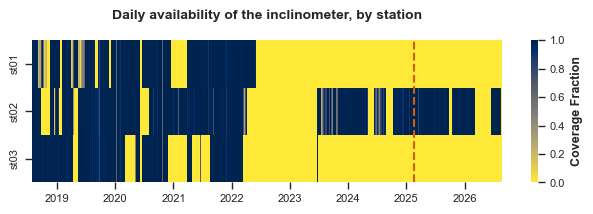

In [11]:
daily_cov = de.coverage_by_period(frames, STATIONS, column=RECORDED_COL, freq='D')

fig = de.plot_coverage_heatmap(
    daily_cov,
    title='Daily availability of the inclinometer, by station',
    tick_when=lambda day: day.month == 1 and day.day == 1, tick_format='%Y',
    height=2.23, marker=CHANGEOVER,
    save_path=OUTPUT_DIR, filename='DE_F03_inclination_coverage')
display(fig)
plt.close(fig)

### Table bodies for the report

The report holds the table headers and `\input`s these bodies, so that a rebuilt
archive never needs a number transcribed by hand.

In [12]:
# These bodies are `\input` directly between a `\midrule` and a `\bottomrule`
# in the report. A LaTeX table row is *separated* from the next by `\\`, not
# *terminated* by it: a trailing `\\` after the last row opens an empty row
# that `\bottomrule` (a `\noalign`) then lands inside, which either breaks
# the build or, if papered over with a bare `\cr`, still typesets as a
# visible blank row. So every row is accumulated first and the rows are
# joined by the separator — the last row must never carry one.
tables.write_table(
    classification, f'{OUTPUT_DIR}/DE_T02_station_classification.tex',
    columns=[
        (lambda r: r.name, tables.texttt),
        ('eras', None),
        (lambda r: r['first_reading'][:10], None),
        (lambda r: r['last_reading'][:10], None),
        ('span_days', '.1f'),
        ('observed_days', '.1f'),
        ('coverage_of_span_%', '.1f'),
    ])

# Coverage is stored as a fraction and published as a percentage, one column per
# station, so the station list drives the column specification.
tables.write_table(
    yearly, f'{OUTPUT_DIR}/DE_T03_yearly_coverage.tex',
    columns=[(lambda r: r.name, None)]
            + [(s, lambda v: format(100 * v, '.1f')) for s in STATIONS])

'outputs/DE_T03_yearly_coverage.tex'

## Step 5 · The instrument changeover

The package installed on 21 February 2025 replaced the legacy unit at station 02. Its
inclinometer is a different instrument and its zero has no guaranteed relation to the
earlier one, so the two are kept in separate columns throughout.

What they are *not* given is separate anchors. `de.coalesce_target` takes the recorded
channel and the recording unit's own air temperature era by era, and only then applies
the compensation and the anchor, once, to the whole series. Compensating and anchoring
each unit separately and concatenating afterwards — which this study previously did —
gives each era its own additive constant and plants a step of order a hundred
millidegrees at the boundary. That step is arithmetic: measured on the recorded channel
the two units agree across the changeover to within a couple of millidegrees. Anchoring
once removes it at the source, so there is no offset left to estimate and no join to
apply.

## Step 6 · Station 02, variable by variable

Station 02 stands at the Porta di Sant'Ubaldo. It is the best-covered record in the
archive and the only one spanning both instrument eras, and it is the station every
later study in this project works on.

### What the four channels look like, era by era

The two eras are summarised separately throughout. Pooling them would average two
unrelated inclinometer baselines into one number, and the standard deviation of that
pooled series would be dominated by the step between the instruments rather than by
anything the wall did.

In [13]:
summary = de.summary_by_era(df, CHANNELS)
display(summary)
summary.to_csv(f'{OUTPUT_DIR}/DE_04_summary_by_era_{STATION}.csv')

# The index is (era, channel), so both come off `r.name`.
tables.write_table(
    summary, f'{OUTPUT_DIR}/DE_T04_summary_by_era.tex',
    columns=[
        (lambda r: r.name[0], None),
        (lambda r: r.name[1], tables.texttt),
        ('count', ',.0f'),
        ('mean', '.2f'),
        ('sd', '.2f'),
        ('min', '.2f'),
        ('median', '.2f'),
        ('max', '.2f'),
    ])

count     mean      sd       min   median      max
era     channel                                                      
legacy  inc_comp  117617  114.494  51.618   -55.700  111.500  232.175
        tair      117617   13.368   8.490    -4.730   11.310   39.370
        rh        117621   74.637  21.173    18.100   78.780   99.960
        batt      117621    3.809   0.354     3.280    3.750    4.740
current inc_comp   30198   84.357  83.662 -1619.400   93.875  175.575
        tair       30198   16.232   9.030    -5.300   15.065   38.950
        rh         30198   75.113  20.861    22.770   79.338  100.300
        batt       30198    4.166   0.394     3.251    4.220    5.157

'outputs/DE_T04_summary_by_era.tex'

### Inclination

The compensated series, which is the measurement this project works on. Its absolute
level carries no structural information — it is set by how the instrument sat in its
mount at installation — so the level is referred to an arbitrary anchor within each
era and only its changes are interpreted.

The middle panel is the offset procedure of step 5, drawn: the two horizontal levels
are the window means either side of the changeover, and their difference is the raw
step the estimate starts from. The lower panel is the joined series, with the
estimated offset removed.

### Why the vertical axis is clipped

The current era carries a handful of readings that are an order of magnitude larger
than anything else in the eight-year record — the archive minimum is −1495.3 mdeg,
reached in July 2026, against an ordinary current-era spread of a few tens of mdeg
either side of zero. Left on a plain linear axis, those few points compress the
whole seasonal shape of the record into a thin band at the top of the plot, which is
exactly the shape this figure exists to show. Panels (a) and (c) below are therefore
drawn on a robust axis range that excludes the extreme tails of each series; panel
(b), a close-range zoom on the changeover that never reaches the affected part of
the record, is left untouched. Nothing is removed from the data or from any computed
statistic — the clipping is a display choice only — and each clipped panel is
annotated with how many samples fall outside its visible range and how deep the
most extreme of them goes. The true minimum remains fully reported in
`DE_04_summary_by_era_st02.csv` and `DE_T04_summary_by_era.tex`.

The clipping itself is `de.robust_limits`, parameterised by `ROBUST_QUANTILES` and
`ROBUST_PAD` in the parameter cell.

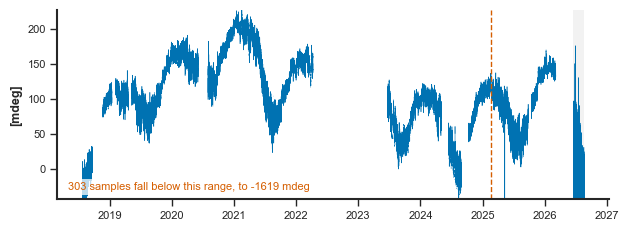

In [14]:
limits_a, n_outside_a = de.robust_limits(
    df['inc_comp'], *ROBUST_QUANTILES, pad=ROBUST_PAD)

fig = de.plot_inclination_series(
    df, 'inc_comp', changeover=CHANGEOVER, span_start=ANOMALY_START,
    limits=limits_a, height=2.4,
    note=(f'{n_outside_a} samples fall below this range, to '
          f'{df["inc_comp"].min():.0f} mdeg') if n_outside_a else None,
    save_path=OUTPUT_DIR, filename=f'DE_F04_{STATION}_inclination')
display(fig)
plt.close(fig)

### The summer 2026 anomaly

From 18 June 2026 to the end of the archive the record carries negative excursions far
larger than anything earlier in the series. The period is compared here against the
average of the same calendar days in every preceding year, so that the ordinary
seasonal shape is separated from whatever is peculiar to 2026.

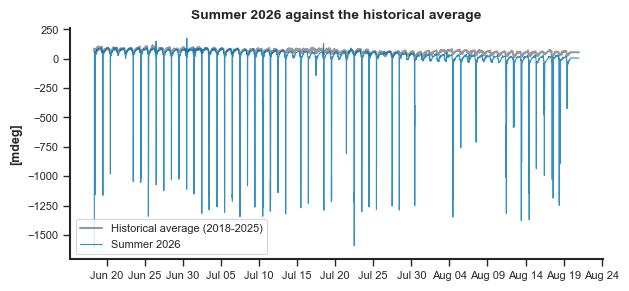

Correlation with historical average: 0.271


In [15]:
# The reference window's edges are taken from the anomaly itself rather than written
# out, so that it keeps following the end of the archive as the record grows.
anomaly_end = df.index[-1]
anomaly_series, aligned_hist = de.anomaly_and_reference(
    df, ANOMALY_COL, ANOMALY_START, anomaly_end, HISTORICAL_END)

fig = de.plot_anomaly_comparison(
    aligned_hist, anomaly_series,
    title='Summer 2026 against the historical average',
    series_label='Summer 2026', reference_label=HISTORICAL_LABEL,
    linewidth=0.8, height=3.0, day_interval=ANOMALY_TICK_DAYS,
    save_path=OUTPUT_DIR, filename=f'DE_F05_{STATION}_summer2026_anomaly')
display(fig)
plt.close(fig)

valid_idx = anomaly_series.index.intersection(aligned_hist.dropna().index)
corr = anomaly_series.loc[valid_idx].corr(aligned_hist.loc[valid_idx])
print(f"Correlation with historical average: {corr:.3f}")

How far outside the rest of the record these excursions sit. The threshold is not a
filter — nothing is removed here — only a line drawn an order of magnitude beyond the
ordinary current-era spread, so that the extreme population can be counted and dated
separately from the record it is buried in.

In [16]:
current_inc = df.loc[df['era'] == 'current', ANOMALY_COL].dropna()
legacy_inc = df.loc[df['era'] == 'legacy', ANOMALY_COL].dropna()
extreme, ordinary = de.extreme_excursions(current_inc, EXCURSION_LIMIT)

print(f'current era: {len(current_inc):,} observed samples, {len(extreme):,} below '
      f'{EXCURSION_LIMIT:.0f} mdeg ({100 * len(extreme) / len(current_inc):.2f}%)')
print(f'  first {extreme.index.min()}, last {extreme.index.max()}')
for month, row in de.excursions_by_month(extreme).iterrows():
    print(f'    {month}: {int(row["n"]):4d} samples, minimum {row["minimum"]:9.1f} mdeg, '
          f'on {int(row["days"])} days')
q01, q99 = ordinary.quantile([0.01, 0.99])
print(f'  excluding them: median {ordinary.median():.1f} mdeg, '
      f'1st to 99th percentile {q01:.0f} to {q99:+.0f} mdeg')
print(f'  legacy era, whole range: {legacy_inc.min():.1f} to '
      f'{legacy_inc.max():+.1f} mdeg')
print(f"Std dev of 2026 anomaly: {anomaly_series.std():.1f} mdeg")
print(f"Std dev of historical average: {aligned_hist.std():.1f} mdeg")



current era: 30,198 observed samples, 119 below -300 mdeg (0.39%)
  first 2025-05-10 14:40:00, last 2026-08-19 11:00:00
    2025-05:    1 samples, minimum    -655.4 mdeg, on 1 days
    2026-06:   19 samples, minimum   -1619.4 mdeg, on 11 days
    2026-07:   57 samples, minimum   -1592.8 mdeg, on 25 days
    2026-08:   42 samples, minimum   -1378.0 mdeg, on 12 days
  excluding them: median 94.1 mdeg, 1st to 99th percentile -9 to +156 mdeg
  legacy era, whole range: -55.7 to +232.2 mdeg
Std dev of 2026 anomaly: 181.9 mdeg
Std dev of historical average: 17.0 mdeg


### Filtering the impulsive noise

The excursions are isolated spikes rather than a sustained movement, so they are removed
with a Hampel filter — a rolling median absolute deviation test — over a 24-hour window.
The filter is chosen because it discards isolated outliers while leaving genuine step
changes intact, which a linear smoother would not.

The filter runs over the whole record rather than over the era that motivated it. The
legacy era carries impulsive noise at a comparable rate, and a dataset whose treatment
changes at a date in the middle cannot be compared across that date. Every replaced
sample is marked in the exported dataset, so an interpolated value is never mistaken for
a measured one.

legacy  :  3073 of 117624 observed samples replaced (2.61%)
current :   927 of  30191 observed samples replaced (3.07%)
legacy   recorded thermal slope +1.19 mdeg/degC, r = +0.24, on 114,544 paired samples, spikes excluded
current  recorded thermal slope +0.57 mdeg/degC, r = +0.34, on 29,271 paired samples, spikes excluded


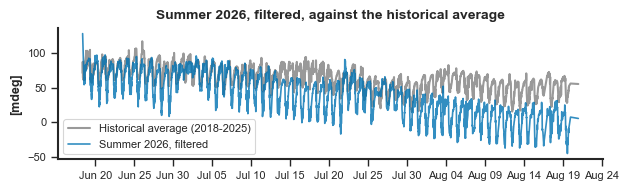

In [17]:
# The filter runs over the whole record, not only the era that motivated it. A dataset
# whose treatment changes at a date in the middle is a trap for anything downstream: the
# two halves would not be comparable, and nothing in the file would say so. The legacy era
# carries impulsive noise at a comparable rate, so the same test is the right one for it.
observed = wide['inc_comp'].dropna()
filtered, outliers = de.hampel_filter(observed, window_size=HAMPEL_WINDOW,
                                      n_sigmas=HAMPEL_SIGMAS, floor=HAMPEL_FLOOR)
wide['inc_comp_cleaned'] = filtered.reindex(wide.index)
wide['inc_spike'] = outliers.reindex(wide.index, fill_value=False)
frames[STATION] = df = de.target_view(wide)

for era_name, row in de.spike_replacement_summary(df, CHANGEOVER).iterrows():
    print(f'{era_name:8s}: {int(row["replaced"]):5d} of {int(row["observed"]):6d} observed '
          f'samples replaced ({row["pct"]:.2f}%)')

# The thermal slope of the channel as recorded, now that the impulsive samples can be
# excluded from it. The embankment geometry predicts that heating tips the wall towards the
# mountain, a negative change by the instrument's convention, while the compensation
# subtracts 5 mdeg/degC. The slope of the *recorded* channel decides whether that
# subtraction is correcting the sign or producing it.
#
# This is a coarse estimate and is reported as one: a single regression over a whole era
# mixes the diurnal response with the annual cycle and with whatever drift the record
# carries, and the correlations are weak. It supports only the claim made from it -- that
# the recorded slope is positive on both instruments and smaller in magnitude than the
# coefficient the compensation removes -- and it is not a measurement of the instrument's
# thermal response.
# `tair` is already the recording unit's own air temperature, era by era.
for era_name, row in de.recorded_thermal_slope(df).iterrows():
    print(f'{era_name:8s} recorded thermal slope {row["slope"]:+.2f} mdeg/degC, '
          f'r = {row["r"]:+.2f}, on {int(row["n"]):,} paired samples, '
          f'spikes excluded')

# DE_F06 plots only the summer 2026 window, so that it can be read against DE_F05
filtered_anomaly = df.loc[ANOMALY_START:anomaly_end, 'inc_comp_cleaned'].dropna()

fig = de.plot_anomaly_comparison(
    aligned_hist, filtered_anomaly,
    title='Summer 2026, filtered, against the historical average',
    series_label='Summer 2026, filtered', reference_label=HISTORICAL_LABEL,
    linewidth=1.2, height=2.0, day_interval=ANOMALY_TICK_DAYS,
    save_path=OUTPUT_DIR, filename=f'DE_F06_{STATION}_summer2026_filtered')
display(fig)
plt.close(fig)

### The full cleaned series

The record as every later study receives it: thermally compensated, with the instrument
offset removed and the impulsive noise filtered out.

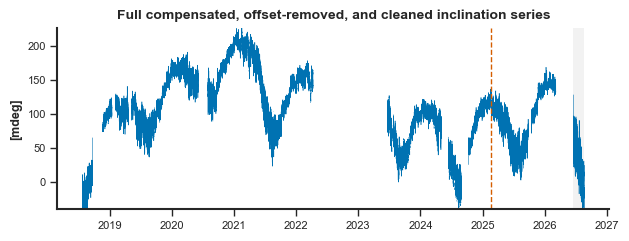

In [18]:
limits_c, n_outside_c = de.robust_limits(
    df['inc_comp_cleaned'], *ROBUST_QUANTILES, pad=ROBUST_PAD)

fig = de.plot_inclination_series(
    df, 'inc_comp_cleaned', changeover=CHANGEOVER, span_start=ANOMALY_START,
    limits=limits_c, height=2.5,
    title='Full compensated, offset-removed, and cleaned inclination series',
    save_path=OUTPUT_DIR, filename=f'DE_F07_{STATION}_inclination_cleaned')
display(fig)
plt.close(fig)

### Seasonal diurnal cycles

The wall's response to the daily heating cycle is the clearest periodic signal in the
record, and its amplitude is the quantity that changes most visibly across the
instrument changeover. The average cycle is drawn era by era and season by season —
summer is June to August, winter December to February, the two extremes of the Central
Italian year — with every complete day of the group behind it in gray.

Each cycle is centred on its own daily mean before averaging. Centring removes the slow
seasonal drift, which would otherwise dominate the average and hide the shape of the
day; what survives is the diurnal excursion alone. Only days with all 72 slots of the
native grid present are used, so that a partly observed day cannot bias the mean
towards the part of the day it happens to cover.

The same treatment is applied below to the air temperature and the relative humidity.
Those two are environmental drivers rather than structural responses, and reading their
cycles beside the inclination is what makes the lag between forcing and response
visible.

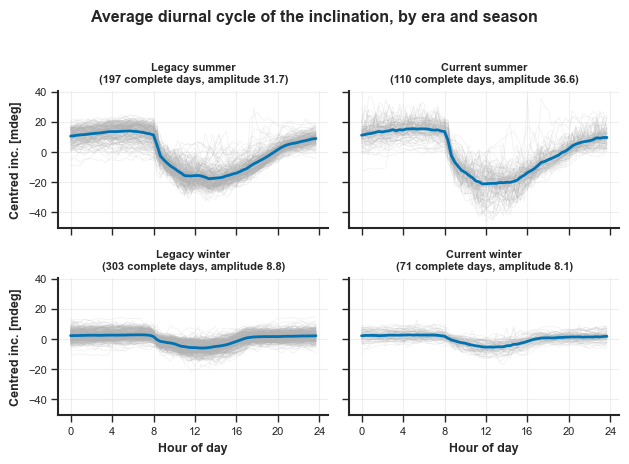

In [19]:
fig, stats_inc = de.diurnal_cycle_grid(
    df, 'inc_comp_cleaned', changeover=CHANGEOVER, season_months=SEASON_MONTHS,
    complete_day=COMPLETE_DAY, colour=INC_COLOUR,
    ylabel='Centred inc. [mdeg]',
    suptitle='Average diurnal cycle of the inclination, by era and season',
    seasons=DIURNAL_SEASONS, eras=ERAS,
    save_path=OUTPUT_DIR, filename=f'DE_F08_{STATION}_diurnal_cycles')
display(fig)
plt.close(fig)

### Air temperature

The air temperature measured at the station itself, over the whole archive, and then
its average diurnal cycle under the same treatment as the inclination. It is the
driver the wall responds to, so its cycle is the reference against which the phase of
the structural response is read.

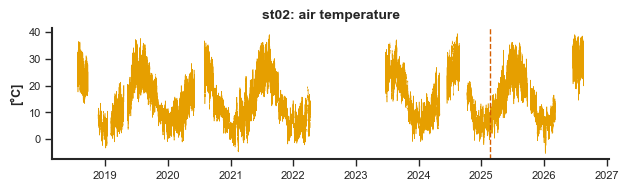

In [20]:
fig = de.plot_channel_series(
    df, 'tair', changeover=CHANGEOVER,
    title=f'{STATION}: {viz.channel_name("tair").lower()}',
    save_path=OUTPUT_DIR, filename=f'DE_F09_{STATION}_tair')
display(fig)
plt.close(fig)

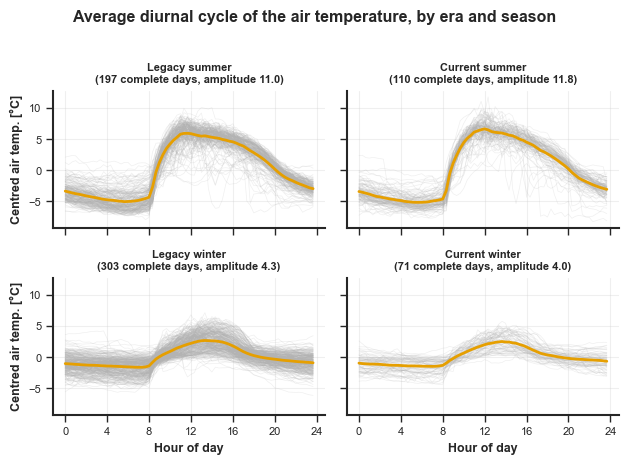

In [21]:
fig, stats_tair = de.diurnal_cycle_grid(
    df, 'tair', changeover=CHANGEOVER, season_months=SEASON_MONTHS,
    complete_day=COMPLETE_DAY, colour=CHANNEL_COLOUR['tair'],
    ylabel='Centred air temp. [°C]',
    suptitle='Average diurnal cycle of the air temperature, by era and season',
    seasons=DIURNAL_SEASONS, eras=ERAS,
    save_path=OUTPUT_DIR, filename=f'DE_F10_{STATION}_tair_diurnal_cycles')
display(fig)
plt.close(fig)

### Relative humidity

The relative humidity, and its diurnal cycle. Relative humidity is not an independent
driver: at roughly constant water content it falls as the air warms and rises as it
cools, so its cycle is expected to run against the temperature rather than with it.
Drawing it here makes that anti-phase relationship checkable rather than assumed.

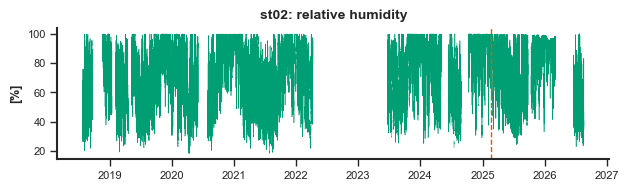

In [22]:
fig = de.plot_channel_series(
    df, 'rh', changeover=CHANGEOVER,
    title=f'{STATION}: {viz.channel_name("rh").lower()}',
    save_path=OUTPUT_DIR, filename=f'DE_F11_{STATION}_rh')
display(fig)
plt.close(fig)

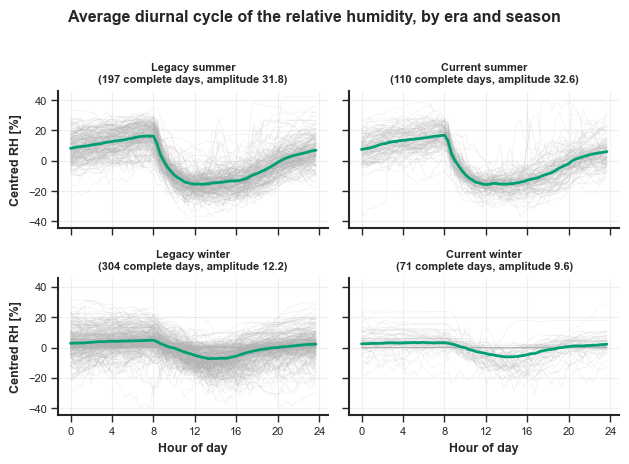

In [23]:
fig, stats_rh = de.diurnal_cycle_grid(
    df, 'rh', changeover=CHANGEOVER, season_months=SEASON_MONTHS,
    complete_day=COMPLETE_DAY, colour=CHANNEL_COLOUR['rh'],
    ylabel='Centred RH [%]',
    suptitle='Average diurnal cycle of the relative humidity, by era and season',
    seasons=DIURNAL_SEASONS, eras=ERAS,
    save_path=OUTPUT_DIR, filename=f'DE_F12_{STATION}_rh_diurnal_cycles')
display(fig)
plt.close(fig)

### Supply voltage

The supply voltage is not a structural quantity: it is the acquisition system's own
health, and it is shown because it is the channel that explains the outages.

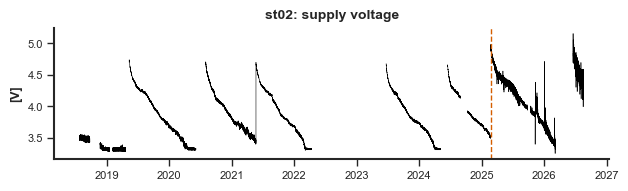

In [24]:
fig = de.plot_channel_series(
    df, 'batt', changeover=CHANGEOVER,
    title=f'{STATION}: {viz.channel_name("batt").lower()}',
    save_path=OUTPUT_DIR, filename=f'DE_F13_{STATION}_batt')
display(fig)
plt.close(fig)

### The summer 2026 anomaly across the channels

The impulsive noise of Step 6 was found on the inclination. Whether it is a property of
the wall, of the site, or of the acquisition system is decided by whether the other
channels carry it over the same days. A real thermal or hygric event has to appear in the
air temperature or the relative humidity, because those are what measure the environment;
a fault in the acquisition chain need not appear in them at all.

Each channel is reduced to its departure from its own 24-hour rolling median, which
removes the diurnal and seasonal shape and leaves the short-lived part of the signal. The
scale of that departure is measured on the current era *before* the anomaly begins, so the
threshold is set by each channel's own ordinary behaviour and the two periods are judged
on identical terms.

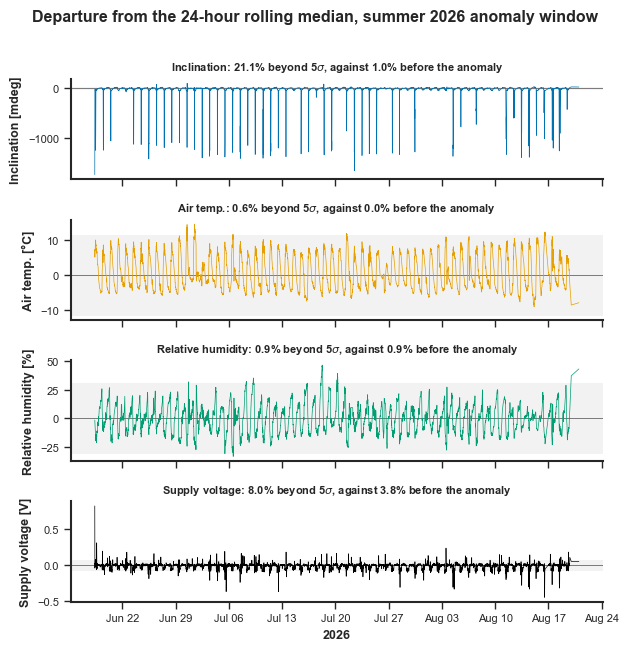

,channel,scale,pct_beyond_before,pct_beyond_during,max_abs_residual_before,max_abs_residual_during,n_excursions,pct_negative,pct_in_daylight
0,inc_comp,5.041,1.05,21.08,748.58,1727.40,925,97.6,97.9
1,tair,2.331,0.01,0.59,18.58,14.69,26,0.0,100.0
2,rh,6.249,0.87,0.91,47.35,46.58,40,7.5,10.0
3,batt,0.015,3.80,8.04,0.64,0.82,353,82.2,82.4


inc_comp           925 excursions,  97.6% negative,  97.9% between 09:00 and 16:00
tair                26 excursions,   0.0% negative, 100.0% between 09:00 and 16:00
rh                  40 excursions,   7.5% negative,  10.0% between 09:00 and 16:00
batt               353 excursions,  82.2% negative,  82.4% between 09:00 and 16:00


In [25]:
anomaly_stats, anomaly_residuals, anomaly_limits, excursion_index = de.anomaly_by_channel(
    df, ANOMALY_CHANNELS, start=CHANGEOVER,
    anomaly_start=ANOMALY_START, anomaly_end=anomaly_end,
    window=RESIDUAL_WINDOW, n_sigmas=OUTLIER_SIGMAS,
    daylight_hours=DAYLIGHT_HOURS)

fig = de.plot_anomaly_channels(
    anomaly_residuals, anomaly_limits, ANOMALY_CHANNELS, labels=ANOMALY_LABEL,
    anomaly_start=ANOMALY_START, anomaly_end=anomaly_end,
    n_sigmas=OUTLIER_SIGMAS,
    suptitle=('Departure from the 24-hour rolling median, '
              'summer 2026 anomaly window'),
    xlabel='2026', day_interval=ANOMALY_PANEL_TICK_DAYS,
    save_path=OUTPUT_DIR, filename=f'DE_F14_{STATION}_anomaly_channels')
display(fig)
plt.close(fig)

display(anomaly_stats)
for _, row in anomaly_stats.iterrows():
    if row['n_excursions']:
        print(f'{row["channel"]:17s} {row["n_excursions"]:4d} excursions, '
              f'{row["pct_negative"]:5.1f}% negative, '
              f'{row["pct_in_daylight"]:5.1f}% between 09:00 and 16:00')
anomaly_stats.to_csv(f'{OUTPUT_DIR}/DE_05_anomaly_by_channel.csv', index=False)

Whether the inclination excursions keep company with the supply-voltage ones is the one
question the table above cannot answer, because it counts each channel separately. The
comparison is made against what independence would produce: if the two channels excurred
without reference to each other, the share of inclination excursions landing in a slot
that also carries a voltage excursion would be the voltage's own excursion rate.

In [26]:
inc_hits = excursion_index[ANOMALY_COL]
together = de.coincidence(inc_hits, excursion_index['batt'],
                          n_slots=len(df.loc[ANOMALY_START:anomaly_end]))

print(f'{together["shared"]} of {len(inc_hits)} inclination excursions fall in the same '
      f'slot as a supply-voltage excursion '
      f'({100 * together["shared"] / len(inc_hits):.0f}%)')
print(f'  independence would give {together["expected"]:.0f}; observed is '
      f'{together["ratio"]:.1f} times that')

# The scale carries its channel's unit in the same cell, so that cell is composed
# rather than formatted: the unit is LaTeX and must not be escaped.
tables.write_table(
    anomaly_stats, f'{OUTPUT_DIR}/DE_T05_anomaly_by_channel.tex',
    columns=[
        (lambda r: ANOMALY_LABEL[r['channel']].split(' [')[0], None),
        (lambda r: f'{r["scale"]:.3f} {CHANNEL_UNIT_TEX[r["channel"]]}', None),
        ('pct_beyond_before', '.2f'),
        ('pct_beyond_during', '.2f'),
        ('max_abs_residual_before', '.1f'),
        ('max_abs_residual_during', '.1f'),
    ])

208 of 925 inclination excursions fall in the same slot as a supply-voltage excursion (22%)
  independence would give 71; observed is 2.9 times that


'outputs/DE_T05_anomaly_by_channel.tex'

### The diurnal cycles, tabulated

The amplitudes and phases behind the three grids above, gathered into one table so that
the report can quote them without a number being transcribed by hand.

In [27]:
diurnal_stats = pd.concat([stats_inc, stats_tair, stats_rh], ignore_index=True)
display(diurnal_stats)
diurnal_stats.to_csv(f'{OUTPUT_DIR}/DE_06_diurnal_cycles.csv', index=False)

# A season with no complete day has no amplitude and no phase, and the three cells
# fall to the missing marker on their own: `amplitude` is NaN there, and the two
# clock cells read it through `de.clock_cell`.
tables.write_table(
    diurnal_stats, f'{OUTPUT_DIR}/DE_T06_diurnal_cycles.tex',
    columns=[
        (lambda r: DIURNAL_NAME[r['channel']], None),
        ('era', None),
        ('season', None),
        ('complete_days', '.0f'),
        (lambda r: (f'{r["amplitude"]:.1f} {CHANNEL_UNIT_TEX[r["channel"]]}'
                    if pd.notna(r['amplitude']) else None), None),
        (lambda r: de.clock_cell(r, 'peak_hour'), None),
        (lambda r: de.clock_cell(r, 'trough_hour'), None),
    ])

,channel,era,season,complete_days,amplitude,peak_hour,trough_hour
0,inc_comp_cleaned,legacy,summer,197,31.71,5.666667,13.333333
1,inc_comp_cleaned,current,summer,110,36.57,5.000000,11.666667
2,inc_comp_cleaned,legacy,winter,303,8.76,6.666667,12.666667
3,inc_comp_cleaned,current,winter,71,8.14,4.666667,12.666667
4,tair,legacy,summer,197,11.01,11.666667,5.666667
5,tair,current,summer,110,11.84,12.000000,5.666667
6,tair,legacy,winter,303,4.32,13.333333,7.000000
7,tair,current,winter,71,4.01,13.666667,7.000000
8,rh,legacy,summer,197,31.77,7.333333,12.666667
9,rh,current,summer,110,32.59,8.000000,12.000000


'outputs/DE_T06_diurnal_cycles.tex'

### The response normalised by its driver

The amplitude of the structural response means little until the amplitude of the forcing
that produced it is known. A summer that was warmer than the one before it will enlarge
the inclination cycle without anything about the wall or the instrument having changed.

Dividing the inclination amplitude by the air-temperature amplitude of the same complete
days removes that. What remains is a sensitivity in millidegrees per degree Celsius, and
it is the quantity to compare across the changeover: an instrument whose gain changed
would move it, and a season that was merely warmer would not.

In [28]:
response = de.diurnal_response(
    diurnal_stats, response_channel=RESPONSE_COL, driver_channel=DRIVER_COL,
    seasons=DIURNAL_SEASONS, eras=ERAS)
display(response)
response.to_csv(f'{OUTPUT_DIR}/DE_07_diurnal_response.csv', index=False)

# The two comparisons the report reads from this: the bare amplitude ratio across the
# changeover, which still carries the season, and the normalised one, which does not.
for season, row in de.response_ratios(response, seasons=DIURNAL_SEASONS).iterrows():
    print(f'{season:7s}: amplitude ratio current/legacy '
          f'{row["amplitude_ratio"]:.2f}, response ratio '
          f'{row["response_ratio"]:.3f} '
          f'({100 * (row["response_ratio"] - 1):+.1f}%)')

tables.write_table(
    response, f'{OUTPUT_DIR}/DE_T07_diurnal_response.tex',
    columns=[
        ('season', None),
        ('era', None),
        ('complete_days', ',.0f'),
        ('inc_amplitude_mdeg', '.1f'),
        ('tair_amplitude_degC', '.1f'),
        ('response_mdeg_per_degC', '.2f'),
    ])

,season,era,complete_days,inc_amplitude_mdeg,tair_amplitude_degC,response_mdeg_per_degC
0,summer,legacy,197,31.71,11.01,2.880
1,summer,current,110,36.57,11.84,3.089
2,winter,legacy,303,8.76,4.32,2.028
3,winter,current,71,8.14,4.01,2.030


summer : amplitude ratio current/legacy 1.15, response ratio 1.073 (+7.3%)
winter : amplitude ratio current/legacy 0.93, response ratio 1.001 (+0.1%)


'outputs/DE_T07_diurnal_response.tex'

## Step 7 · The current era: wall temperature and solar radiation

Two channels arrived with the package installed on 21 February 2025 and exist nowhere in
the legacy record: the wall temperature, measured by a probe set into the masonry, and the
solar radiation. Nothing in this step spans the archive. Every number below is conditioned
on eighteen months, and the wall probe is not available even across all of those.

The pair is worth its own step because between them they carry what the air temperature
only stands in for. The air is not what deforms the wall — the wall's own temperature is,
and that is set as much by the sun falling on the exposed face as by the air around it.

In [29]:
current = df.loc[CHANGEOVER:]

availability = de.current_era_availability(
    current, AVAILABILITY_CHANNELS, SEASON_MONTHS, complete_day=COMPLETE_DAY)
display(availability)
availability.to_csv(f'{OUTPUT_DIR}/DE_08_current_era_availability.csv', index=False)

tables.write_table(
    availability, f'{OUTPUT_DIR}/DE_T08_current_era_availability.tex',
    columns=[
        ('channel', tables.texttt),
        ('observed', ','),
        ('pct_of_era', '.1f'),
    ] + [(f'complete_days_{season}', '.0f') for season in SEASON_MONTHS])

,channel,observed,pct_of_era,complete_days_winter,complete_days_spring,complete_days_summer,complete_days_autumn
0,inc_comp_cleaned,30191,76.8,71,76,110,55
1,tair,30191,76.8,71,76,110,55
2,rh,30191,76.8,71,76,110,55
3,batt,30191,76.8,71,76,110,55
4,twall,14625,37.2,6,73,78,0
5,sr,27091,68.9,71,74,110,20


'outputs/DE_T08_current_era_availability.tex'

### What is actually there

The wall probe is the constraint on everything that follows. It reports for barely more
than a third of the era, in a handful of stretches rather than continuously, and those
stretches fall in spring and summer. Measured on the summer-and-winter pair the four core
channels were compared on, it has one full season and almost nothing of the other — and
the one it is missing is the season that would test it hardest.

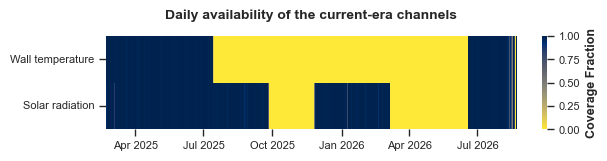

In [30]:
daily_era = pd.DataFrame({
    viz.channel_name(c): current[c].notna().resample('D').mean()
    for c in ERA_CHANNELS})

fig = de.plot_coverage_heatmap(
    daily_era,
    title='Daily availability of the current-era channels',
    tick_when=lambda day: day.day == 1 and day.month % 3 == 1,
    tick_format='%b %Y', height=1.7,
    save_path=OUTPUT_DIR, filename=f'DE_F15_{STATION}_current_era_coverage')
display(fig)
plt.close(fig)

### The wall temperature

The probe set into the masonry. Its record as written first, because
what the raw channel holds over eight months of this era is not a gap.

### The wall probe, as written

The corrected record below shows a gap between July 2025 and June 2026. The raw record
shows what is actually in the archive over those eight months: `-55.0`, on every sample,
the open-circuit sentinel at the bottom of the sensor range. The probe did not stop
reporting — it reported its own failure, continuously, and only the raw channel
distinguishes that from an acquisition unit that was switched off.

This is the difference the study exists to preserve, and the reason it reads the archive
rather than a cleaned dataset.

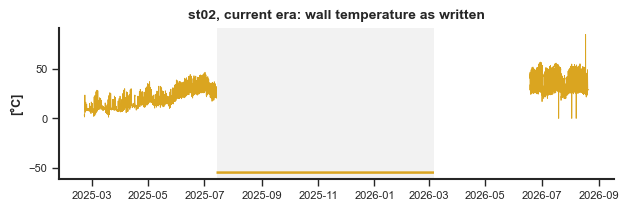

In [31]:
fig = de.plot_twall_raw(
    wide, title=f'{STATION}, current era: wall temperature as written',
    height=2.2, save_path=OUTPUT_DIR, filename=f'DE_F16_{STATION}_twall_raw')
display(fig)
plt.close(fig)

### The filtered record

The sentinel rejection exposes two recording segments. Only the final one, beginning on
18 June 2026, is tested for impulsive anomalies here. A centred three-sample Hampel test
compares each value with its immediate thermal trajectory. Its 10 °C floor lies above
ordinary twenty-minute variability but below every isolated departure found in this
segment. Flagged samples are linearly interpolated; original gaps remain missing, and the
recorded and corrected values remain available beside the filtered result.

,recorded_degC,replacement_degC
timestamp,,
2026-07-01 11:00:00,17.00,43.150
2026-07-19 11:20:00,-0.07,45.090
2026-08-02 15:00:00,-0.07,52.405
2026-08-07 09:20:00,-0.07,31.965
2026-08-17 15:00:00,85.00,39.310


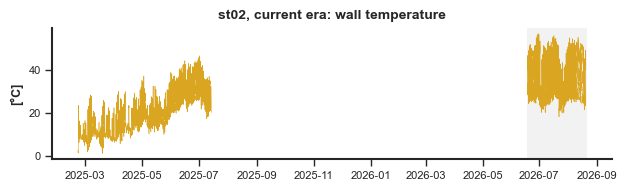

In [32]:
wide['n_twall_filtered'], wide['twall_spike'] = de.filter_impulsive_segment(
    wide['n_twall_ok'],
    start=TWALL_FILTER_START,
    window_size=TWALL_HAMPEL_WINDOW,
    n_sigmas=TWALL_HAMPEL_SIGMAS,
    floor=TWALL_HAMPEL_FLOOR,
)
frames[STATION] = df = de.target_view(wide)
current = df.loc[CHANGEOVER:]

twall_window = current.loc[TWALL_FILTER_START:]
twall_anomalies = pd.DataFrame({
    'recorded_degC': twall_window.loc[twall_window['twall_spike'], 'twall'],
    'replacement_degC': twall_window.loc[twall_window['twall_spike'], 'twall_filtered'],
})
twall_anomalies.index.name = 'timestamp'
display(twall_anomalies)
twall_anomalies.to_csv(f'{OUTPUT_DIR}/DE_12_twall_anomalies.csv', float_format='%.3f')

# The full filtered record. The highlighted interval is the only wall-temperature segment
# subjected to the anomaly test.
fig = de.plot_current_era_series(
    current, 'twall_filtered',
    title=f'{STATION}, current era: {viz.channel_name("twall_filtered").lower()}',
    highlight_start=TWALL_FILTER_START,
    save_path=OUTPUT_DIR, filename=f'DE_F17_{STATION}_twall_filtered')
display(fig)
plt.close(fig)

The final segment before filtering. Vermilion markers identify every sample rejected by
the impulse test; no other channel enters this diagnosis.

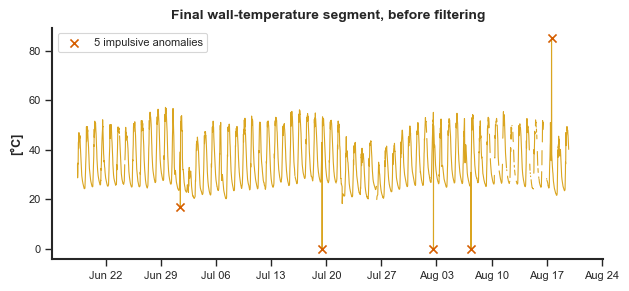

In [33]:
flagged_twall = twall_window[twall_window['twall_spike']]

fig = de.plot_segment(
    twall_window, 'twall',
    title='Final wall-temperature segment, before filtering',
    flagged_column='twall_spike',
    flag_label=f'{len(flagged_twall)} impulsive anomalies',
    linewidth=0.8, height=3.0, day_interval=SEGMENT_TICK_DAYS,
    save_path=OUTPUT_DIR,
    filename=f'DE_F18_{STATION}_twall_final_segment_anomalies')
display(fig)
plt.close(fig)

The same segment after the five isolated impulses are replaced by linear interpolation.

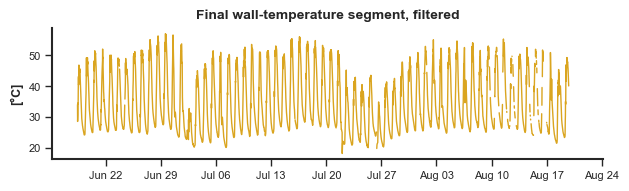

In [34]:
fig = de.plot_segment(
    twall_window, 'twall_filtered',
    title='Final wall-temperature segment, filtered',
    linewidth=1.0, height=2.0, day_interval=SEGMENT_TICK_DAYS,
    save_path=OUTPUT_DIR,
    filename=f'DE_F19_{STATION}_twall_final_segment_filtered')
display(fig)
plt.close(fig)

### Diurnal cycles, and why they are drawn for summer and winter

The same construction as before — complete days only, each centred on its own daily mean.
The panels are seasons rather than eras, since there is only one era here, and the seasons
are summer and winter, the same pair the four core channels were compared on. Holding the
pair fixed is what makes the current-era channels readable against everything before them.

It also makes the cost visible. Neither current-era channel can support a winter
comparison, and they fail for different reasons: the wall probe reports almost nothing in
winter, while the radiation reports plenty and none of it is trustworthy. Substituting
spring would hide both facts behind a full-looking panel.

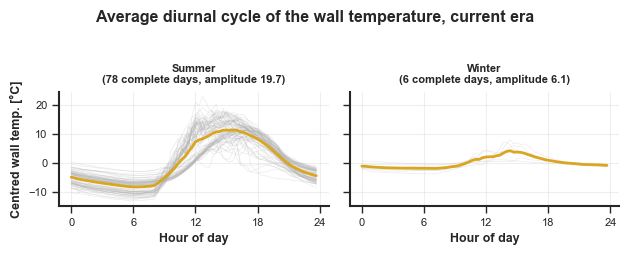

In [35]:
fig, stats_twall = de.diurnal_cycle_pair(
    current, 'twall_filtered', season_months=SEASON_MONTHS,
    complete_day=COMPLETE_DAY, ylabel='Centred wall temp. [°C]',
    suptitle='Average diurnal cycle of the wall temperature, current era',
    seasons=DIURNAL_SEASONS,
    save_path=OUTPUT_DIR, filename=f'DE_F20_{STATION}_twall_diurnal_cycles')
display(fig)
plt.close(fig)

### The solar radiation

The defect first, because it decides what the rest of this section is allowed to say;
then the record carrying it, then the cycle drawn on the days that survive.

### Where the night ends, and what the channel does in it

Two of this study's decisions about the radiation rest on one measurement: the elevation
at which the natural signal is exhausted, and the fact that the condemned days carry no
signal at any elevation. The table below is that measurement, taken on the recorded
values so that the correction under test does not define its own justification.

On working days the radiation decays through twilight and reaches the instrument's own
floor by about -6 degrees, civil twilight. Below that there is no sky brightness left to
lose, so setting those samples to zero destroys nothing; cutting at the geometric horizon
instead would erase real twilight. On condemned days the same table is flat from one end
to the other, which is what having no diurnal cycle looks like when it is tabulated.

In [36]:
elevation_bands = de.sr_by_elevation(wide)
display(elevation_bands)
elevation_bands.to_csv(f'{OUTPUT_DIR}/DE_09_sr_by_elevation.csv', index=False)


# A band that holds no sample has no median and no percentile; those cells fall to
# the missing marker rather than printing a zero the band never measured.
tables.write_table(
    elevation_bands, f'{OUTPUT_DIR}/DE_T09_sr_by_elevation.tex',
    columns=[
        (lambda r: f'{r["elevation_from"]:.0f} to {r["elevation_to"]:.0f}', None),
        ('n_working', ',.0f'),
        ('median_working', '.2f'),
        ('p95_working', '.1f'),
        ('n_condemned', ',.0f'),
        ('median_condemned', '.1f'),
    ])

,elevation_from,elevation_to,n_working,median_working,p95_working,n_condemned,median_condemned
0,-90,-18,3813,0.12,8.6,4506,192.7
1,-18,-12,1020,0.12,10.3,565,162.1
2,-12,-9,437,0.25,8.8,293,174.1
3,-9,-6,417,0.25,9.6,288,178.2
4,-6,-4,303,0.25,8.9,197,179.6
5,-4,-2,278,2.38,12.4,163,170.2
6,-2,0,234,5.38,18.3,211,180.5
7,0,2,290,8.44,29.1,191,186.4
8,2,5,397,19.12,45.1,294,183.6
9,5,10,590,34.31,116.8,495,189.2


'outputs/DE_T09_sr_by_elevation.tex'

### A channel that fails in two ways

The day-level verdict of step 3 asks the question the failure actually poses: does the
radiation reported while the sun is high exceed the radiation reported while it is down?
On a working sensor that ratio is enormous. It collapses to about one in both of this
channel's failure modes -- stuck near a constant, reporting as much at midnight as at
noon; or dead, reporting exactly zero through a summer midday. A threshold on the
deep-night hours alone would catch the first and miss the second entirely.

Neither defect is the `8191.875` wrap-around of the raw-data specification. That artefact
is rare -- 15 samples on 4 days, all in the first fortnight of the current era -- and is
counted under `wrap` in step 2. The stuck window does push part of its plateau above the
1400 W/m² ceiling, and those 3085 samples on 44 days are rejected per sample under
`unphysical`; but the ceiling sees only the tallest part of the defect, and the day-level
verdict is what actually measures its extent. Both failure modes are undocumented, and
the specification should be extended to record them.

In [37]:
sr_bad_days = set(sr_suspect_days)
sr_suspect = df['sr_suspect']

quality = sr_day_quality.set_index('day')
affected = sorted(sr_bad_days)
print(f'{len(affected)} condemned days, {affected[0].date()} to {affected[-1].date()}')
print('  by month, median of the day medians:')
for month, row in de.condemned_by_month(quality).iterrows():
    print(f'    {month}  {int(row["days"]):3d} days   high sun '
          f'{row["sunlit_median"]:7.1f}   dark {row["dark_median"]:7.1f}')

# The two modes partition the condemned days rather than merely describing them, so that
# the counts here and the accounting of the whole failure window below cannot disagree.
# Dead is the sharp test: nothing at all at high sun. Stuck is every other condemned day.
dead, stuck = de.condemned_modes(quality, dead_threshold=SR_DEAD_THRESHOLD)
print(f'\n  stuck near a constant : {len(stuck):3d} days, '
      f'{stuck.index.min().date()} to {stuck.index.max().date()}')
print(f'  dead, zero at high sun: {len(dead):3d} days, '
      f'{dead.index.min().date()} to {dead.index.max().date()}')
print(f'\n{int(sr_suspect.loc[CHANGEOVER:].sum())} of {len(current)} current-era slots '
      f'fall on a condemned day')

161 condemned days, 2025-07-27 to 2026-03-06
  by month, median of the day medians:
    2025-07    5 days   high sun     0.0   dark     0.0
    2025-08   30 days   high sun     0.0   dark     0.0
    2025-09   24 days   high sun     9.2   dark     6.8
    2025-11    6 days   high sun   344.2   dark   308.1
    2025-12   31 days   high sun   222.8   dark   222.8
    2026-01   31 days   high sun   242.4   dark   233.0
    2026-02   28 days   high sun   234.0   dark   206.9
    2026-03    6 days   high sun   144.1   dark   119.6

  stuck near a constant : 111 days, 2025-09-10 to 2026-03-06
  dead, zero at high sun:  50 days, 2025-07-27 to 2025-09-25

11592 of 39313 current-era slots fall on a condemned day


In [38]:
# The extent of the failure, derived from the day-level verdict rather than read off the
# figure. It opens on the first condemned day and closes on the day before the channel
# next produces a day that passes, so the outage that interrupts it is inside the window:
# an instrument that stops recording has not recovered, and the record cannot show that it
# has until it reports again.
sr_fail_start, sr_fail_end, sr_recovery = de.sr_failure_window(quality)

print(f'radiation failure window: {sr_fail_start.date()} to {sr_fail_end.date()} '
      f'({(sr_fail_end - sr_fail_start).days + 1} calendar days)')
print(f'  first day that passes again: {sr_recovery.date()}')

radiation failure window: 2025-07-27 to 2026-06-17 (326 calendar days)
  first day that passes again: 2026-06-18


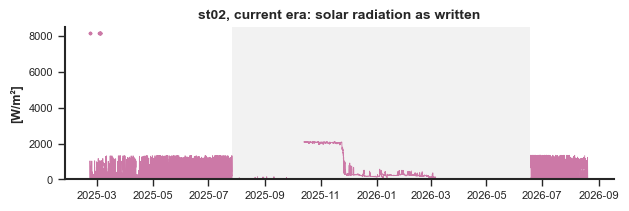

In [39]:
fig = de.plot_sr_raw(
    wide, start=CHANGEOVER, fail_start=sr_fail_start, recovery=sr_recovery,
    title=f'{STATION}, current era: solar radiation as written',
    height=2.2, axis_step=SR_AXIS_STEP,
    save_path=OUTPUT_DIR, filename=f'DE_F21_{STATION}_sr')
display(fig)
plt.close(fig)

### Is any of it usable?

The window is long enough that discarding it wholesale deserves an argument rather than
an assertion. Every day inside it falls into one of five states, and the question is
whether any state contains a day whose radiation could be used.

In [40]:
# Every calendar day in the window gets exactly one state, assigned in the order below so
# that the states partition the window rather than merely describe it. The order runs from
# the most complete failure to the least: a day on which nothing was written cannot also be
# a day on which nothing survived rejection, and a day on which nothing survived cannot be
# judged at all.
window = pd.date_range(sr_fail_start, sr_fail_end, freq='D')
state = de.sr_day_states(wide, quality, window, dead_threshold=SR_DEAD_THRESHOLD)
phases = {name: window[state == name] for name in de.SR_STATES}

print(f'{len(window)} calendar days, {sr_fail_start.date()} to {sr_fail_end.date()}')
for name, days in phases.items():
    span = (f'{days.min().date()} to {days.max().date()}' if len(days) else '---')
    print(f'  {name:48s} {len(days):4d}  {span}')

# The only candidates for a usable day are the ones that pass the ratio test. The test is
# a ratio, so it is blind to scale: a channel reporting a hundredth of the real radiation
# with the right shape passes it. Their absolute level is the test the ratio cannot make.
print('\ndays that pass the ratio test, against the level August and September require:')
for day in phases['passes the ratio test']:
    row = quality.loc[day]
    print(f'  {day.date()}  ratio {row["ratio"]:7.2f}   high-sun median '
          f'{row["sunlit_median"]:7.2f} W/m²')
clean = quality.loc[quality.index < sr_fail_start, 'sunlit_median']
print(f'  for comparison, the median high-sun median before the failure: '
      f'{clean.median():.0f} W/m²')

326 calendar days, 2025-07-27 to 2026-06-17
  no record at all                                  120  2025-09-26 to 2026-06-17
  pegged above the ceiling, every sample rejected    43  2025-10-13 to 2025-11-24
  dead, zero at high sun                             50  2025-07-27 to 2025-09-25
  stuck near a constant                             111  2025-09-10 to 2026-03-06
  passes the ratio test                               2  2025-08-03 to 2025-09-15

days that pass the ratio test, against the level August and September require:
  2025-08-03  ratio   79.00   high-sun median    9.88 W/m²
  2025-09-15  ratio    3.10   high-sun median   19.75 W/m²
  for comparison, the median high-sun median before the failure: 762 W/m²


In [41]:
# The rule for a usable radiation day, stated once here and used by every average that
# follows. A day qualifies when the day-quality test judged it and let it stand, and when
# it falls outside the failure window. The second condition is not implied by the first:
# the window contains days the test could not judge at all, and an unjudged day has not
# been approved by anything. Relying on the condemned flag alone would let them through.
sr_valid_day, sr_valid = de.sr_valid_days(quality, sr_fail_start, sr_fail_end,
                                          current.index)
inside_failure = ((quality.index >= sr_fail_start)
                  & (quality.index <= sr_fail_end))

print(f'{len(sr_valid_day)} of {len(quality.index)} judged days carry usable radiation')
print(f'  excluded as condemned          : {int(quality["condemned"].sum())}')
print(f'  excluded as inside the failure : {int(inside_failure.sum())}')

219 of 382 judged days carry usable radiation
  excluded as condemned          : 161
  excluded as inside the failure : 163


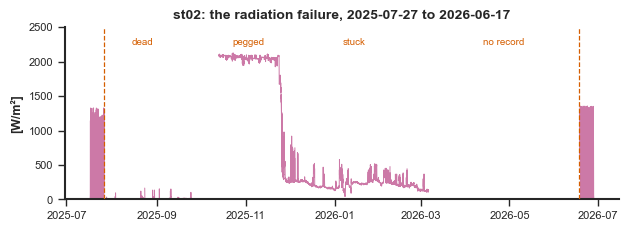

In [42]:
fig = de.plot_sr_failure(
    wide, state, fail_start=sr_fail_start, recovery=sr_recovery,
    title=(f'{STATION}: the radiation failure, {sr_fail_start.date()} to '
           f'{sr_fail_end.date()}'),
    short_labels=SR_STATE_LABEL, margin_days=SR_FAILURE_MARGIN_DAYS,
    height=2.4, axis_step=SR_AXIS_STEP,
    save_path=OUTPUT_DIR, filename=f'DE_F22_{STATION}_sr_failure')
display(fig)
plt.close(fig)

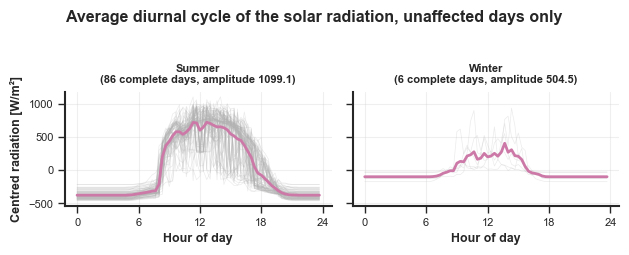

In [43]:
fig, stats_sr = de.diurnal_cycle_pair(
    current, 'sr', season_months=SEASON_MONTHS, complete_day=COMPLETE_DAY,
    ylabel='Centred radiation [W/m²]',
    suptitle='Average diurnal cycle of the solar radiation, unaffected days only',
    seasons=DIURNAL_SEASONS, valid=sr_valid,
    save_path=OUTPUT_DIR, filename=f'DE_F23_{STATION}_sr_diurnal_cycles')
display(fig)
plt.close(fig)

In [44]:
current_era_diurnal = pd.concat([stats_twall, stats_sr], ignore_index=True)
display(current_era_diurnal)
current_era_diurnal.to_csv(f'{OUTPUT_DIR}/DE_11_current_era_diurnal.csv', index=False)

,channel,season,complete_days,amplitude,peak_hour,trough_hour
0,twall_filtered,summer,78,19.71,15.666667,6.333333
1,twall_filtered,winter,6,6.11,14.333333,7.000000
2,sr,summer,86,1099.06,12.666667,NaN
3,sr,winter,6,504.54,13.666667,NaN


### The chain, in one figure

The four quantities that matter, on the same summer days and the same clock: the sun that
arrives, the air it warms, the masonry the air and the sun together heat, and the
deformation that follows. Each cycle is centred and then divided by its own largest
excursion, so that four different units can share an axis; the figure is about *when*,
not about how much.

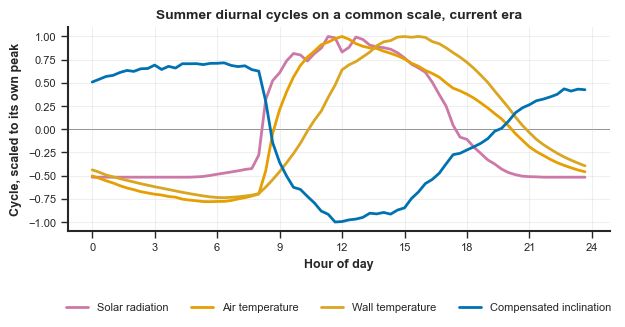

78 summer days complete in all 4 channels, 2025-06-01 to 2026-08-18


,channel,complete_days,amplitude,peak_hour,trough_hour
0,sr,78,1101.05,11.333333,NaN
1,tair,78,12.45,12.000000,5.666667
2,twall_filtered,78,19.71,15.666667,6.333333
3,inc_comp_cleaned,78,40.17,6.333333,11.666667


'outputs/DE_T10_phase_chain.tex'

In [45]:
fig, phase, complete_days = de.phase_chain(
    current, PHASE_CHANNELS, season_months=SEASON_MONTHS,
    complete_day=COMPLETE_DAY, season=PHASE_SEASON, valid=sr_valid,
    title='Summer diurnal cycles on a common scale, current era',
    height=3.3, save_path=OUTPUT_DIR,
    filename=f'DE_F24_{STATION}_phase_chain')
display(fig)
plt.close(fig)

print(f'{len(complete_days)} summer days complete in all {len(PHASE_CHANNELS)} '
      f'channels, {complete_days.min().date()} to {complete_days.max().date()}')

display(phase)
phase.to_csv(f'{OUTPUT_DIR}/DE_10_phase_chain.csv', index=False)

tables.write_table(
    phase, f'{OUTPUT_DIR}/DE_T10_phase_chain.tex',
    columns=[
        (lambda r: viz.channel_name(r['channel']), None),
        ('complete_days', '.0f'),
        (lambda r: f'{r["amplitude"]:.1f} {CHANNEL_UNIT_TEX[r["channel"]]}', None),
        (lambda r: de.clock_cell(r, 'peak_hour'), None),
        (lambda r: de.clock_cell(r, 'trough_hour'), None),
    ])

## Step 8 · The exported archive

The whole archive as one table, on the 20-minute grid, in four groups of columns:

1. **As recorded** — every field of every `.adc` file, unmodified, sentinels included,
   one block per acquisition unit in file order. Legacy block b2 is `st02_*` and the
   current-era package is `n_*`, and they never share a column, because their
   inclinometers share no baseline.
2. **`{column}_flag`** — what was decided about the value. A *rejection* — `sentinel`,
   `wrap`, `unphysical` — says nothing is known in its place. A *correction* — `night` —
   says its true value is known. Empty when the value stands.
3. **`{column}_ok`** — the value the study uses, in the same unit: missing exactly where
   a rejection is set, and carrying the substituted value where a correction is.
4. **Derived** — the inclination in millidegrees and compensated, per block; then the
   target station's chain, `inc` through `inc_comp` to `inc_comp_cleaned`; and
   `n_twall_filtered`. The `inc_spike`, `twall_spike` and `sr_suspect` columns preserve
   the provenance of the three verdicts that condemn a reading without rejecting its
   recorded value.

Later studies should read `inc_comp_cleaned` and `n_twall_filtered`, honouring their
respective `inc_spike` and `twall_spike` flags: an interpolated sample is never a
measured one. Missing samples stay missing — nothing here fills a gap in the record,
only spikes inside it.

Nothing is aggregated. A study needing the hourly grid to align against external proxies
builds it from this table, resampling the values by mean and the flags by any.

A manifest is written beside the table recording the archive extent, the record counts,
every flag total, the offset that was applied and the filter settings, so that the file
can be audited without re-running this notebook.

In [46]:
n_observed = int(wide['inc_comp'].notna().sum())
n_spikes = int(wide['inc_spike'].sum())
n_twall_spikes = int(wide['twall_spike'].sum())

manifest = {
    'produced_by': 'studies/01_data_exploration/data_exploration_study.py',
    'source': 'the raw .adc archive, read directly',
    'archive_extent': [ARCHIVE_START, ARCHIVE_END],
    'freq': ANALYSIS_FREQ,
    'first_timestamp': str(wide.index.min()),
    'last_timestamp': str(wide.index.max()),
    'n_rows': int(len(wide)),
    'n_files': text_stats['files'],
    'records_read': {'legacy': text_stats['n_legacy'],
                     'current': text_stats['n_current'],
                     'rejected_on_field_count': text_stats['rejected']},
    'duplicate_timestamps': {era: stats['duplicates']
                             for era, stats in parse_stats.items()},
    'field_conflicts_merged': {era: stats['conflicts']
                               for era, stats in parse_stats.items()},
    'comma_decimal_fields': text_stats['comma_fields'],
    'mixed_separator_files': text_stats['mixed_separator_files'],
    'flag_counts': flag_counts,
    'n_sr_suspect_days': int(len(sr_bad_days)),
    'site_timezone': de.SITE_TZ,
    'night_elevation_deg': de.NIGHT_ELEVATION,
    'sr_day_ratio': de.SR_DAY_RATIO,
    'compensation_coefficient': de.COMP_COEFF,
    'target_station': STATION,
    'analysis_column': 'inc_comp_cleaned',
    'changeover': str(CHANGEOVER),
    'compensation_anchor': 'single, global: the first slot of the target station '
                           'series carrying both the inclination and the air '
                           'temperature. No per-era anchor and no era join',
    'hampel': {'window_samples': HAMPEL_WINDOW, 'window_hours': HAMPEL_WINDOW / 3,
               'n_sigmas': HAMPEL_SIGMAS, 'floor_mdeg': HAMPEL_FLOOR,
               'scope': 'whole record, both eras'},
    'wall_temperature_hampel': {
        'start': str(TWALL_FILTER_START),
        'window_samples': TWALL_HAMPEL_WINDOW,
        'n_sigmas': TWALL_HAMPEL_SIGMAS,
        'floor_degC': TWALL_HAMPEL_FLOOR,
        'scope': 'final wall-temperature recording segment only',
    },
    'n_observed': n_observed,
    'n_spikes': n_spikes,
    'n_twall_spikes': n_twall_spikes,
    # The schema of the export is the library's, so its documentation comes from there.
    'columns': de.export_column_doc(STATION),
}

written = de.save_archive(wide, EXPORT_DIR, manifest, compress=COMPRESS)

print(f'wrote {written["table"]}  ({written["size_mb"]} MB)')
print(f'      {written["manifest"]}')
print(f'  {len(wide):,} rows at {ANALYSIS_FREQ}, '
      f'{wide.index.min()} to {wide.index.max()}')
print(f'  {len(de.export_columns(wide))} columns')
print(f'  {n_observed:,} observed inclination samples, {n_spikes:,} replaced by the '
      f'filter ({100 * n_spikes / n_observed:.2f}%)')
print(f'  {n_twall_spikes:,} wall-temperature samples replaced in the final segment')
display(wide[de.export_columns(wide)].tail(3))

wrote ../../data/interim/archive/gubbio_archive_20min.csv  (45.6 MB)
      ../../data/interim/archive/gubbio_archive_20min_manifest.json
  212,257 rows at 20min, 2018-07-26 00:00:00 to 2026-08-21 00:00:00
  71 columns
  147,815 observed inclination samples, 4,000 replaced by the filter (2.71%)
  5 wall-temperature samples replaced in the final segment


,era,st01_batt,st01_tair,st01_rh,st01_i_mv,st02_batt,st02_tair,st02_rh,st02_i_mv,st03_batt,st03_tair,st03_rh,st03_i_mv,n_batt,n_tair,n_rh,n_i_mv,n_sr,n_twall,st01_batt_flag,...,n_rh_ok,n_i_mv_ok,n_sr_ok,n_twall_ok,st01_inc,st01_inc_comp,st02_inc,st02_inc_comp,st03_inc,st03_inc_comp,n_inc,n_inc_comp,inc,tair,inc_comp,inc_comp_cleaned,inc_spike,n_twall_filtered,twall_spike,sr_suspect
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-08-20 23:20:00,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,False,False
2026-08-20 23:40:00,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,False,False
2026-08-21 00:00:00,current,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.433,25.75,82.68,2148.5,5.25,29.25,,...,82.68,2148.5,0.0,29.25,NaN,NaN,NaN,NaN,NaN,NaN,-351.5,-111.7,-351.5,25.75,5.4,5.4,False,29.25,False,False
